# Water Pipe Renewal Priority Analysis

## 1. Setup and Load Data

This notebook is structured as a lightweight portfolio workflow. The early steps focus on understanding the input dataset and confirming which fields are likely to support later analysis.

In [1]:
import os
from datetime import datetime
from pathlib import Path

PROJECT_ROOT = Path.cwd()
MPL_CONFIG_DIR = PROJECT_ROOT / ".matplotlib"
MPL_CONFIG_DIR.mkdir(parents=True, exist_ok=True)
os.environ["MPLCONFIGDIR"] = str(MPL_CONFIG_DIR.resolve())

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = Path("../data/raw")
OUTPUT_PATH = Path("../outputs")
CHART_PATH = OUTPUT_PATH / "charts"
TABLE_PATH = OUTPUT_PATH / "tables"

TABLE_PATH.mkdir(parents=True, exist_ok=True)
CHART_PATH.mkdir(parents=True, exist_ok=True)

## 2. Data Understanding

This section confirms which raw file is being used, the size of the dataset, and the main fields available. The goal here is to understand the structure of the data before any cleaning, quality assessment, or scoring is attempted.

This analysis uses the `Regional Water Pipes` dataset from Wellington Water Open Data:  
[https://data-wellingtonwater.opendata.arcgis.com/datasets/d264f8d5c8bb4c519412b7ed86d5bcb8_0/about](https://data-wellingtonwater.opendata.arcgis.com/datasets/d264f8d5c8bb4c519412b7ed86d5bcb8_0/about)

The local CSV file used for this project is:  
`Regional_Water_Pipes_2925950293390148246.csv`

### Load the raw CSV file

The notebook checks the `data/raw/` folder, loads the available CSV file, and reports the basic dataset size. If multiple CSV files are present, the first file is used and the selected file name is printed clearly.

In [2]:
csv_files = sorted(DATA_PATH.glob("*.csv"))

if not csv_files:
    raise FileNotFoundError("No CSV files were found in data/raw/.")

selected_file = csv_files[0]

if len(csv_files) == 1:
    print(f"Loaded CSV file: {selected_file.name}")
else:
    print(f"Multiple CSV files found in data/raw/. Using the first file: {selected_file.name}")

df = pd.read_csv(selected_file, low_memory=False)

print(f"File name: {selected_file.name}")
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]:,}")

Loaded CSV file: Regional_Water_Pipes_2925950293390148246.csv


File name: Regional_Water_Pipes_2925950293390148246.csv
Number of rows: 253,690
Number of columns: 35


### Review the basic dataset structure

The following checks are intended to give a quick business-friendly overview of what is in the file: sample rows, column names, data types, non-null counts, and high-level summary statistics.

In [3]:
df.head()

,OBJECTID,Asset ID,Start_Node_ID,End_Node_ID,Operational Status,System Type,Pipe Type,Pipe Use,Pipe Class,Owner,...,Acquisition_Code,Acquisition Date,Historic ID,Key,Plan Reference,Region,Notes,uid,globalid,Shape__Length
0,1,GWRC_CI_PWP000001,GWRC_PW000684,GWRC_PW102565,In Use,Potable Water,Main,NaN,NaN,GWRC,...,NaN,NaN,115645,NaN,NaN,Greater Wellington,Old InfoAsset ID: WW-VLVNG001 - WW-VLV027,52FF2E65D8EE44AF98C1978DB1879543,24a99882-6a9e-4353-ad26-078afb7b4e44,0.615549
1,2,GWRC_CI_PWP000002,GWRC_PW000689,GWRC_PW000650,In Use,Potable Water,Main,Pressure,NaN,GWRC,...,NaN,NaN,NaN,NaN,NaN,Greater Wellington,Old InfoAsset ID: GWRC_PWP002666,8CC33AA5931D45879C0293E5AC0455DB,ec2e3190-16dd-4c1f-95b1-986b60d73332,492.794498
2,3,GWRC_CI_PWP000003,GWRC_PW000686,GWRC_PW103375,In Use,Potable Water,Main,Pressure,NaN,GWRC,...,NaN,NaN,NaN,NaN,NaN,Greater Wellington,Old InfoAsset ID: GWRC_PWP002667,87AC7281D50B4D268A6B2E5E31BDDF22,e193cac7-3114-44c2-be95-d8c6a655b159,0.316708
3,4,GWRC_CI_PWP000004,GWRC_PW000685,GWRC_PW103370,In Use,Potable Water,Main,Pressure,NaN,GWRC,...,NaN,NaN,NaN,NaN,NaN,Greater Wellington,Old InfoAsset ID: GWRC_PWP002668,C30846015103483985C228722DA1BABE,8cb711dc-bd52-453c-8b2d-a719a5c876aa,13.794944
4,5,GWRC_CI_PWP000005,GWRC_CI_PW000005,GWRC_PW000650,In Use,Potable Water,Main,Pressure,NaN,GWRC,...,NaN,NaN,WSP011243,NaN,NaN,Greater Wellington,Old InfoAsset ID: GWRC_PWP002669,3E026DAA7C02402FBAA124CAE1874354,5094ab92-3eff-417f-924a-bfe208a781b1,2.375211


In [4]:
column_names = pd.DataFrame({"column_name": df.columns})
column_names

,column_name
0,OBJECTID
1,Asset ID
2,Start_Node_ID
3,End_Node_ID
4,Operational Status
5,System Type
6,Pipe Type
7,Pipe Use
8,Pipe Class
9,Owner


In [5]:
dataset_info = pd.DataFrame({
    "column_name": df.columns,
    "data_type": df.dtypes.astype(str).values,
    "non_null_count": df.notna().sum().values
})

dataset_info

,column_name,data_type,non_null_count
0,OBJECTID,int64,253690
1,Asset ID,str,253690
2,Start_Node_ID,str,175435
3,End_Node_ID,str,179019
4,Operational Status,str,253689
5,System Type,str,253690
6,Pipe Type,str,253683
7,Pipe Use,str,183505
8,Pipe Class,str,29786
9,Owner,str,253688


In [6]:
df.describe(include="all").transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
OBJECTID,253690.0,NaN,NaN,NaN,126845.5,73234.139233,1.0,63423.25,126845.5,190267.75,253690.0
Asset ID,253690,253690,GWRC_CI_PWP000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Start_Node_ID,175435,155510,0,787,NaN,NaN,NaN,NaN,NaN,NaN,NaN
End_Node_ID,179019,165995,0,797,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Operational Status,253689,7,In Use,231288,NaN,NaN,NaN,NaN,NaN,NaN,NaN
System Type,253690,1,Potable Water,253690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pipe Type,253683,13,Service Connection,142522,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pipe Use,183505,4,Pressure,182705,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pipe Class,29786,29,PN16,25138,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner,253688,12,WCC,105517,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Create a field summary table

This table provides a practical field reference for the project. It combines simple completeness counts with a rule-based interpretation of what each field may represent and how it could be used later in the portfolio analysis.

In [7]:
def infer_field_meaning(column_name: str):
    name = column_name.lower()

    if any(keyword in name for keyword in ["asset id", "asset_id", "objectid", "globalid", "uid", "historic id", "historic_id", "key"]):
        return (
            "Unique or system asset identifier",
            "Duplicate checks and asset-level analysis"
        )

    if "material" in name:
        return (
            "Pipe material",
            "Asset profile and material-based scoring later"
        )

    if any(keyword in name for keyword in ["diameter", "size"]):
        return (
            "Pipe size or nominal diameter",
            "Asset profile and criticality proxy later"
        )

    if "length" in name:
        return (
            "Pipe segment length",
            "Length summaries and exposure context later"
        )

    if any(keyword in name for keyword in ["install", "acquisition", "construction", "date"]):
        return (
            "Date-related asset information",
            "Potential asset age input if confirmed suitable"
        )

    if any(keyword in name for keyword in ["suburb", "region", "council", "area", "zone", "location"]):
        return (
            "Location or service area grouping",
            "Regional summaries if suitable"
        )

    if any(keyword in name for keyword in ["geometry", "geom", "shape"]):
        return (
            "Spatial or geometry information",
            "Retained but not used in this lightweight non-GIS analysis"
        )

    if any(keyword in name for keyword in ["status", "condition", "criticality", "owner", "maintenance", "system", "type", "use", "class"]):
        return (
            "Operational or asset classification field",
            "Potential descriptive context for later review"
        )

    return ("To be reviewed", "To be reviewed")

field_summary = pd.DataFrame({
    "column_name": df.columns,
    "data_type": df.dtypes.astype(str).values,
    "non_null_count": df.notna().sum().values,
})
field_summary["missing_count"] = len(df) - field_summary["non_null_count"]
field_summary["missing_rate"] = (field_summary["missing_count"] / len(df)).round(4)
example_values = []
business_meanings = []
analysis_uses = []
for column in df.columns:
    non_null_values = df[column].dropna()
    if df[column].dtype == "object":
        non_null_values = non_null_values[non_null_values.astype(str).str.strip() != ""]
    example_value = non_null_values.iloc[0] if not non_null_values.empty else np.nan
    possible_business_meaning, use_in_analysis = infer_field_meaning(column)
    example_values.append(example_value)
    business_meanings.append(possible_business_meaning)
    analysis_uses.append(use_in_analysis)
field_summary["example_value"] = example_values
field_summary["possible_business_meaning"] = business_meanings
field_summary["use_in_analysis"] = analysis_uses
field_summary = field_summary[["column_name", "data_type", "non_null_count", "missing_count", "missing_rate", "example_value", "possible_business_meaning", "use_in_analysis"]]
field_summary.to_csv(TABLE_PATH / "data_field_summary.csv", index=False)
field_summary

,column_name,data_type,non_null_count,missing_count,missing_rate,example_value,possible_business_meaning,use_in_analysis
0,OBJECTID,int64,253690,0,0.0000,1,Unique or system asset identifier,Duplicate checks and asset-level analysis
1,Asset ID,str,253690,0,0.0000,GWRC_CI_PWP000001,Unique or system asset identifier,Duplicate checks and asset-level analysis
2,Start_Node_ID,str,175435,78255,0.3085,GWRC_PW000684,To be reviewed,To be reviewed
3,End_Node_ID,str,179019,74671,0.2943,GWRC_PW102565,To be reviewed,To be reviewed
4,Operational Status,str,253689,1,0.0000,In Use,Operational or asset classification field,Potential descriptive context for later review
5,System Type,str,253690,0,0.0000,Potable Water,Operational or asset classification field,Potential descriptive context for later review
6,Pipe Type,str,253683,7,0.0000,Main,Operational or asset classification field,Potential descriptive context for later review
7,Pipe Use,str,183505,70185,0.2767,Pressure,Operational or asset classification field,Potential descriptive context for later review
8,Pipe Class,str,29786,223904,0.8826,UK,Operational or asset classification field,Potential descriptive context for later review
9,Owner,str,253688,2,0.0000,GWRC,Operational or asset classification field,Potential descriptive context for later review


### Confirm Key Analytical Fields

Before data quality checks, asset profile analysis, and renewal priority screening, the key analytical fields are defined based on the project objective.

This project needs fields that describe:

- asset identity
- operational status
- system type
- material
- pipe size
- pipe length
- installation age
- decommissioning status
- operational zone
- condition
- criticality

The field mapping below is a manually confirmed project mapping. It reflects the intended analytical structure for this portfolio project and should be treated as the working reference for later tasks.

In [8]:
key_field_mapping = pd.DataFrame([
    {"analytical_role": "Unique asset identifier", "selected_dataset_column": "Asset ID", "business_meaning": "Primary identifier for each pipe asset record", "use_in_analysis": "Main asset-level identifier across the project", "notes": "Use Asset ID as the main asset identifier rather than OBJECTID, Historic ID, or Key."},
    {"analytical_role": "Operational status", "selected_dataset_column": "Operational Status", "business_meaning": "Indicates whether the asset is currently in service or otherwise operationally classified", "use_in_analysis": "Context field for later asset interpretation", "notes": "Retain as an operational context field for later review."},
    {"analytical_role": "System type", "selected_dataset_column": "System Type", "business_meaning": "Describes the broad water system classification for the pipe asset", "use_in_analysis": "Used to confirm the portfolio context of the records", "notes": "Retain to confirm the asset group being analysed."},
    {"analytical_role": "Material", "selected_dataset_column": "Material", "business_meaning": "Pipe material type", "use_in_analysis": "Used for asset profile review and later material-based screening", "notes": "Retain as a core descriptive and analytical field."},
    {"analytical_role": "Diameter", "selected_dataset_column": "Diameter_mm", "business_meaning": "Pipe diameter in millimetres", "use_in_analysis": "Used for pipe size analysis and later criticality proxy review", "notes": "Retain as the primary pipe size field."},
    {"analytical_role": "Length", "selected_dataset_column": "Length_m", "business_meaning": "Pipe segment length in metres", "use_in_analysis": "Used for pipe length summaries and later exposure context", "notes": "Length_m should be used for pipe length summaries."},
    {"analytical_role": "Install date", "selected_dataset_column": "Date Installed", "business_meaning": "Recorded installation date for the pipe asset", "use_in_analysis": "Primary date field for later asset age estimation", "notes": "Date Installed should be used to estimate asset age. Acquisition Date should be retained as a reference field but should not be used as the primary age field."},
    {"analytical_role": "Decommission date", "selected_dataset_column": "Date Decommissioned", "business_meaning": "Date the pipe asset was decommissioned, if applicable", "use_in_analysis": "Later review of decommissioning status and asset lifecycle context", "notes": "Retain to understand whether an asset remains active in the current portfolio."},
    {"analytical_role": "Operational zone", "selected_dataset_column": "DMA Zone", "business_meaning": "Operational zone or district metered area grouping", "use_in_analysis": "Used for zone-level summaries if appropriate", "notes": "DMA Zone should be used for zone-level summaries if the field is sufficiently complete."},
    {"analytical_role": "Condition", "selected_dataset_column": "Condition Grade", "business_meaning": "Condition-related field indicating the recorded state of the asset", "use_in_analysis": "Potential later input to renewal screening, subject to validation", "notes": "Condition Grade should be checked in the next task before deciding whether it can be used in priority scoring."},
    {"analytical_role": "Criticality", "selected_dataset_column": "Criticality", "business_meaning": "Recorded criticality or importance indicator for the asset", "use_in_analysis": "Potential later input to renewal screening, subject to validation", "notes": "Criticality should be checked in the next task before deciding whether it can be used in priority scoring."},
])
key_field_mapping.to_csv(TABLE_PATH / "key_field_mapping.csv", index=False)
key_field_mapping

,analytical_role,selected_dataset_column,business_meaning,use_in_analysis,notes
0,Unique asset identifier,Asset ID,Primary identifier for each pipe asset record,Main asset-level identifier across the project,Use Asset ID as the main asset identifier rath...
1,Operational status,Operational Status,Indicates whether the asset is currently in se...,Context field for later asset interpretation,Retain as an operational context field for lat...
2,System type,System Type,Describes the broad water system classificatio...,Used to confirm the portfolio context of the r...,Retain to confirm the asset group being analysed.
3,Material,Material,Pipe material type,Used for asset profile review and later materi...,Retain as a core descriptive and analytical fi...
4,Diameter,Diameter_mm,Pipe diameter in millimetres,Used for pipe size analysis and later critical...,Retain as the primary pipe size field.
5,Length,Length_m,Pipe segment length in metres,Used for pipe length summaries and later expos...,Length_m should be used for pipe length summar...
6,Install date,Date Installed,Recorded installation date for the pipe asset,Primary date field for later asset age estimation,Date Installed should be used to estimate asse...
7,Decommission date,Date Decommissioned,"Date the pipe asset was decommissioned, if app...",Later review of decommissioning status and ass...,Retain to understand whether an asset remains ...
8,Operational zone,DMA Zone,Operational zone or district metered area grou...,Used for zone-level summaries if appropriate,DMA Zone should be used for zone-level summari...
9,Condition,Condition Grade,Condition-related field indicating the recorde...,"Potential later input to renewal screening, su...",Condition Grade should be checked in the next ...


### Optional helper check

The optional code below provides a simple keyword-based helper check against the dataset columns. It is included only as a support step to compare against the manual field mapping above. It is not the decision-making method used for the project field selection.

In [9]:
def find_candidate_fields(columns, keywords):
    matches = []
    for column in columns:
        column_lower = column.lower()
        if any(keyword in column_lower for keyword in keywords):
            matches.append(column)
    return matches
helper_candidate_fields = {
    "asset_id_field": find_candidate_fields(df.columns, ["asset id", "asset_id", "objectid", "globalid", "uid", "historic id", "historic_id", "key"]),
    "material_field": find_candidate_fields(df.columns, ["material"]),
    "diameter_field": find_candidate_fields(df.columns, ["diameter", "size"]),
    "length_field": find_candidate_fields(df.columns, ["length"]),
    "date_field": find_candidate_fields(df.columns, ["install", "acquisition", "construction", "date"]),
    "region_field": find_candidate_fields(df.columns, ["suburb", "region", "council", "area", "zone", "location"]),
    "geometry_field": find_candidate_fields(df.columns, ["geometry", "geom", "shape"]),
}
for field_name, candidates in helper_candidate_fields.items():
    print(field_name)
    if not candidates:
        print("  No clear candidate found")
    elif len(candidates) == 1:
        print(f"  {candidates[0]}")
    else:
        print(f"  {candidates} (helper check only)")


asset_id_field
  ['OBJECTID', 'Asset ID', 'Historic ID', 'Key', 'uid', 'globalid'] (helper check only)
material_field
  Material
diameter_field
  Diameter_mm
length_field
  ['Length_m', 'Shape__Length'] (helper check only)
date_field
  ['Date Installed', 'Date Decommissioned', 'Date Lined', 'External Protection_Date', 'Acquisition_Code', 'Acquisition Date'] (helper check only)
region_field
  ['DMA Zone', 'Region'] (helper check only)
geometry_field
  Shape__Length


## 3. Data Quality Assessment

This section checks whether the confirmed analytical fields are complete enough, valid enough, and consistent enough to support later portfolio analysis. The focus here is not to make renewal decisions yet. It is to prepare an analysis-ready working dataset and identify where records may need review before they are used in later screening.

### Create a working copy for data quality review

The raw CSV remains unchanged. A working copy is created so the confirmed fields can be standardised for internal analysis without altering the source data.

In [10]:
working_df = df.copy()
column_mapping = {
    "Asset ID": "asset_id",
    "Operational Status": "operational_status",
    "System Type": "system_type",
    "Material": "material",
    "Diameter_mm": "diameter_mm",
    "Length_m": "length_m",
    "Date Installed": "date_installed",
    "Date Decommissioned": "date_decommissioned",
    "DMA Zone": "dma_zone",
    "Condition Grade": "condition_grade",
    "Criticality": "criticality",
}
analysis_df = working_df[list(column_mapping.keys())].rename(columns=column_mapping).copy()
analysis_df.head()

,asset_id,operational_status,system_type,material,diameter_mm,length_m,date_installed,date_decommissioned,dma_zone,condition_grade,criticality
0,GWRC_CI_PWP000001,In Use,Potable Water,STCL,375.0,0.62,1/1/1979 12:00:00 AM,NaN,CBD,2.0,NaN
1,GWRC_CI_PWP000002,In Use,Potable Water,CI,525.0,492.79,1/1/1911 12:00:00 AM,NaN,CBD,NaN,NaN
2,GWRC_CI_PWP000003,In Use,Potable Water,CI,525.0,0.32,1/1/1911 12:00:00 AM,NaN,WCC CBD West,NaN,NaN
3,GWRC_CI_PWP000004,In Use,Potable Water,STCL,375.0,13.80,1/1/1911 12:00:00 AM,NaN,CBD,NaN,NaN
4,GWRC_CI_PWP000005,In Use,Potable Water,NaN,150.0,2.37,1/1/1968 12:00:00 AM,NaN,CBD,NaN,0.0


### Convert data types for internal use

Several fields need to be converted before quality checks can be applied consistently. Numeric conversion helps identify invalid size or length values, and date conversion supports later checks on installation timing and asset age.

In [11]:
analysis_df["diameter_mm"] = pd.to_numeric(analysis_df["diameter_mm"], errors="coerce")
analysis_df["length_m"] = pd.to_numeric(analysis_df["length_m"], errors="coerce")
analysis_df["date_installed"] = pd.to_datetime(analysis_df["date_installed"], errors="coerce", format="mixed")
analysis_df["date_decommissioned"] = pd.to_datetime(analysis_df["date_decommissioned"], errors="coerce", format="mixed")
analysis_df["condition_grade"] = pd.to_numeric(analysis_df["condition_grade"], errors="coerce")
analysis_df["criticality"] = pd.to_numeric(analysis_df["criticality"], errors="coerce")
analysis_df.dtypes

asset_id                          str
operational_status                str
system_type                       str
material                          str
diameter_mm                   float64
length_m                      float64
date_installed         datetime64[us]
date_decommissioned    datetime64[us]
dma_zone                          str
condition_grade               float64
criticality                   float64
dtype: object

### Create basic derived fields for quality review

A simple asset age field is created from the installation year only. This is used for data quality checking rather than decision-making. A decommissioned flag is also created to capture records that have either a decommission date or an operational status that suggests the asset is no longer active.

In [12]:
current_year = datetime.now().year
analysis_df["asset_age"] = np.where(analysis_df["date_installed"].notna(), current_year - analysis_df["date_installed"].dt.year, np.nan)
status_text = analysis_df["operational_status"].fillna("").astype(str).str.lower()
inactive_status_mask = status_text.str.contains("decommission|abandon|retir|inactive|removed|out of service|closed", regex=True)
analysis_df["is_decommissioned"] = analysis_df["date_decommissioned"].notna() | inactive_status_mask
analysis_df[["asset_id", "date_installed", "asset_age", "operational_status", "date_decommissioned", "is_decommissioned"]].head()

,asset_id,date_installed,asset_age,operational_status,date_decommissioned,is_decommissioned
0,GWRC_CI_PWP000001,1979-01-01,47.0,In Use,NaT,False
1,GWRC_CI_PWP000002,1911-01-01,115.0,In Use,NaT,False
2,GWRC_CI_PWP000003,1911-01-01,115.0,In Use,NaT,False
3,GWRC_CI_PWP000004,1911-01-01,115.0,In Use,NaT,False
4,GWRC_CI_PWP000005,1968-01-01,58.0,In Use,NaT,False


### Run completeness checks

Completeness checks show how much of each confirmed analytical field is populated. This helps identify whether a field is ready to support later analysis or whether it may need caution or review.

In [13]:
confirmed_fields = ["asset_id", "operational_status", "system_type", "material", "diameter_mm", "length_m", "date_installed", "date_decommissioned", "dma_zone", "condition_grade", "criticality"]
completeness_summary = pd.DataFrame({"field_name": confirmed_fields, "non_null_count": [analysis_df[field].notna().sum() for field in confirmed_fields]})
completeness_summary["missing_count"] = len(analysis_df) - completeness_summary["non_null_count"]
completeness_summary["missing_rate"] = (completeness_summary["missing_count"] / len(analysis_df)).round(4)
completeness_summary.to_csv(TABLE_PATH / "completeness_summary.csv", index=False)
completeness_summary

,field_name,non_null_count,missing_count,missing_rate
0,asset_id,253690,0,0.0000
1,operational_status,253689,1,0.0000
2,system_type,253690,0,0.0000
3,material,199622,54068,0.2131
4,diameter_mm,243321,10369,0.0409
5,length_m,253685,5,0.0000
6,date_installed,201113,52577,0.2072
7,date_decommissioned,15291,238399,0.9397
8,dma_zone,250192,3498,0.0138
9,condition_grade,247971,5719,0.0225


### Run validity checks

Validity checks look for values that are missing when they should be present, or values that may require review before later portfolio analysis. Examples include missing IDs, non-positive diameter values, missing installation dates, and unusually old ages that may need manual review.

In [14]:
validity_checks = {
    "missing asset_id": analysis_df["asset_id"].isna() | analysis_df["asset_id"].astype(str).str.strip().eq(""),
    "duplicate asset_id": analysis_df["asset_id"].fillna("").astype(str).str.strip().ne("") & analysis_df["asset_id"].duplicated(keep=False),
    "diameter_mm <= 0": analysis_df["diameter_mm"].notna() & (analysis_df["diameter_mm"] <= 0),
    "missing diameter_mm": analysis_df["diameter_mm"].isna(),
    "length_m <= 0": analysis_df["length_m"].notna() & (analysis_df["length_m"] <= 0),
    "missing length_m": analysis_df["length_m"].isna(),
    "missing material": analysis_df["material"].isna() | analysis_df["material"].astype(str).str.strip().eq(""),
    "missing date_installed": analysis_df["date_installed"].isna(),
    "date_installed in the future": analysis_df["date_installed"].notna() & (analysis_df["date_installed"].dt.year > current_year),
    "asset_age < 0": analysis_df["asset_age"].notna() & (analysis_df["asset_age"] < 0),
    "asset_age > 150": analysis_df["asset_age"].notna() & (analysis_df["asset_age"] > 150),
    "missing operational_status": analysis_df["operational_status"].isna() | analysis_df["operational_status"].astype(str).str.strip().eq(""),
    "missing dma_zone": analysis_df["dma_zone"].isna() | analysis_df["dma_zone"].astype(str).str.strip().eq(""),
    "missing condition_grade": analysis_df["condition_grade"].isna(),
    "missing criticality": analysis_df["criticality"].isna(),
}
validity_summary = pd.DataFrame({"issue_name": list(validity_checks.keys()), "issue_count": [int(mask.sum()) for mask in validity_checks.values()]})
validity_summary["issue_rate"] = (validity_summary["issue_count"] / len(analysis_df)).round(4)
validity_summary.to_csv(TABLE_PATH / "validity_summary.csv", index=False)
validity_summary

,issue_name,issue_count,issue_rate
0,missing asset_id,0,0.0000
1,duplicate asset_id,0,0.0000
2,diameter_mm <= 0,19319,0.0762
3,missing diameter_mm,10369,0.0409
4,length_m <= 0,18,0.0001
5,missing length_m,5,0.0000
6,missing material,54068,0.2131
7,missing date_installed,52577,0.2072
8,date_installed in the future,1,0.0000
9,asset_age < 0,1,0.0000


### Run consistency checks on key categorical fields

Consistency checks provide a simple view of how key categorical fields are recorded. They do not clean the values yet, but they help show whether the data contains mixed labels, blanks, or categories that may need closer review in later steps.

In [15]:
def export_value_counts(series, output_name, display_name):
    value_counts = series.fillna("Missing").astype(str).replace({"": "Missing"}).value_counts(dropna=False).rename_axis(display_name).reset_index(name="count")
    value_counts.to_csv(TABLE_PATH / output_name, index=False)
    return value_counts
material_value_counts = export_value_counts(analysis_df["material"], "material_value_counts.csv", "material")
operational_status_value_counts = export_value_counts(analysis_df["operational_status"], "operational_status_value_counts.csv", "operational_status")
system_type_value_counts = export_value_counts(analysis_df["system_type"], "system_type_value_counts.csv", "system_type")
dma_zone_value_counts = export_value_counts(analysis_df["dma_zone"], "dma_zone_value_counts.csv", "dma_zone")
condition_grade_value_counts = export_value_counts(analysis_df["condition_grade"], "condition_grade_value_counts.csv", "condition_grade")
criticality_value_counts = export_value_counts(analysis_df["criticality"], "criticality_value_counts.csv", "criticality")
material_value_counts.head(10)

,material,count
0,Missing,54068
1,PE80,51201
2,CU,39575
3,PE100,29058
4,AC,24388
5,STCL,11611
6,CI,9199
7,UPVC,5844
8,uPVC,5233
9,GI,4450


### Create data quality flags and issue reasons

Each asset is assigned a single overall data quality flag using the project severity order: `Data Review Required`, `Major Issue`, `Minor Issue`, then `Complete`. These are project-defined screening rules only. They are not official asset condition ratings. Missing decommission dates are only treated as a minor issue when the operational status suggests the asset is no longer active.

In [16]:
def build_quality_flag(row):
    reasons = []
    op_missing = pd.isna(row["operational_status"]) or str(row["operational_status"]).strip() == ""
    system_missing = pd.isna(row["system_type"]) or str(row["system_type"]).strip() == ""
    status_text = "" if op_missing else str(row["operational_status"]).strip().lower()
    inactive_status = any(term in status_text for term in ["decommission", "abandon", "retir", "inactive", "removed", "out of service", "closed"])
    missing_decommission_for_inactive = inactive_status and pd.isna(row["date_decommissioned"])

    data_review_required_checks = [
        (pd.isna(row["asset_id"]) or str(row["asset_id"]).strip() == "", "Missing asset ID"),
        (pd.isna(row["material"]) or str(row["material"]).strip() == "", "Missing material"),
        (pd.isna(row["diameter_mm"]), "Missing diameter"),
        (pd.notna(row["diameter_mm"]) and row["diameter_mm"] <= 0, "Invalid diameter"),
        (pd.isna(row["length_m"]), "Missing length"),
        (pd.notna(row["length_m"]) and row["length_m"] <= 0, "Invalid length"),
        (pd.isna(row["date_installed"]), "Missing install date"),
        (pd.notna(row["date_installed"]) and row["date_installed"].year > current_year, "Install date in the future"),
        (pd.notna(row["asset_age"]) and row["asset_age"] < 0, "Negative asset age"),
    ]
    major_issue_checks = [
        (pd.isna(row["condition_grade"]), "Missing condition grade"),
        (pd.isna(row["criticality"]), "Missing criticality"),
        (pd.isna(row["dma_zone"]) or str(row["dma_zone"]).strip() == "", "Missing DMA zone"),
        (pd.notna(row["asset_age"]) and row["asset_age"] > 150, "Very old asset age"),
    ]
    minor_issue_checks = [
        (op_missing, "Missing operational status"),
        (system_missing, "Missing system type"),
        (missing_decommission_for_inactive, "Missing decommission date for inactive asset"),
    ]

    if any(check for check, _ in data_review_required_checks):
        flag = "Data Review Required"
        reasons = [message for check, message in data_review_required_checks if check]
    elif any(check for check, _ in major_issue_checks):
        flag = "Major Issue"
        reasons = [message for check, message in major_issue_checks if check]
    elif any(check for check, _ in minor_issue_checks):
        flag = "Minor Issue"
        reasons = [message for check, message in minor_issue_checks if check]
    else:
        flag = "Complete"
        reasons = ["Complete key fields"]

    return pd.Series([flag, "; ".join(reasons)])

analysis_df[["data_quality_flag", "data_quality_issue_reason"]] = analysis_df.apply(build_quality_flag, axis=1)
data_quality_flag_summary = analysis_df["data_quality_flag"].value_counts().rename_axis("data_quality_flag").reset_index(name="asset_count")
data_quality_flag_summary["percentage_of_total"] = (data_quality_flag_summary["asset_count"] / len(analysis_df)).round(4)
data_quality_flag_summary.to_csv(TABLE_PATH / "data_quality_flag_summary.csv", index=False)
data_quality_flag_summary

,data_quality_flag,asset_count,percentage_of_total
0,Complete,120513,0.4750
1,Major Issue,68463,0.2699
2,Data Review Required,62381,0.2459
3,Minor Issue,2333,0.0092


### Export the cleaned analysis-ready dataset

The working dataset below is exported for later tasks. It includes the simplified analytical columns, the derived quality-review fields, and the overall data quality flag and reason for each asset.

In [17]:
cleaned_output_columns = ["asset_id", "operational_status", "system_type", "material", "diameter_mm", "length_m", "date_installed", "date_decommissioned", "dma_zone", "condition_grade", "criticality", "asset_age", "is_decommissioned", "data_quality_flag", "data_quality_issue_reason"]
pipe_assets_cleaned = analysis_df[cleaned_output_columns].copy()
pipe_assets_cleaned.to_csv(TABLE_PATH / "pipe_assets_cleaned.csv", index=False)
pipe_assets_cleaned.head()

,asset_id,operational_status,system_type,material,diameter_mm,length_m,date_installed,date_decommissioned,dma_zone,condition_grade,criticality,asset_age,is_decommissioned,data_quality_flag,data_quality_issue_reason
0,GWRC_CI_PWP000001,In Use,Potable Water,STCL,375.0,0.62,1979-01-01,NaT,CBD,2.0,NaN,47.0,False,Major Issue,Missing criticality
1,GWRC_CI_PWP000002,In Use,Potable Water,CI,525.0,492.79,1911-01-01,NaT,CBD,NaN,NaN,115.0,False,Major Issue,Missing condition grade; Missing criticality
2,GWRC_CI_PWP000003,In Use,Potable Water,CI,525.0,0.32,1911-01-01,NaT,WCC CBD West,NaN,NaN,115.0,False,Major Issue,Missing condition grade; Missing criticality
3,GWRC_CI_PWP000004,In Use,Potable Water,STCL,375.0,13.80,1911-01-01,NaT,CBD,NaN,NaN,115.0,False,Major Issue,Missing condition grade; Missing criticality
4,GWRC_CI_PWP000005,In Use,Potable Water,NaN,150.0,2.37,1968-01-01,NaT,CBD,NaN,0.0,58.0,False,Data Review Required,Missing material


### Create a simple missing value chart

A single chart is created to show the missing rate across the confirmed analytical fields. This provides a quick visual summary of which fields are likely to constrain later analysis if left untreated.

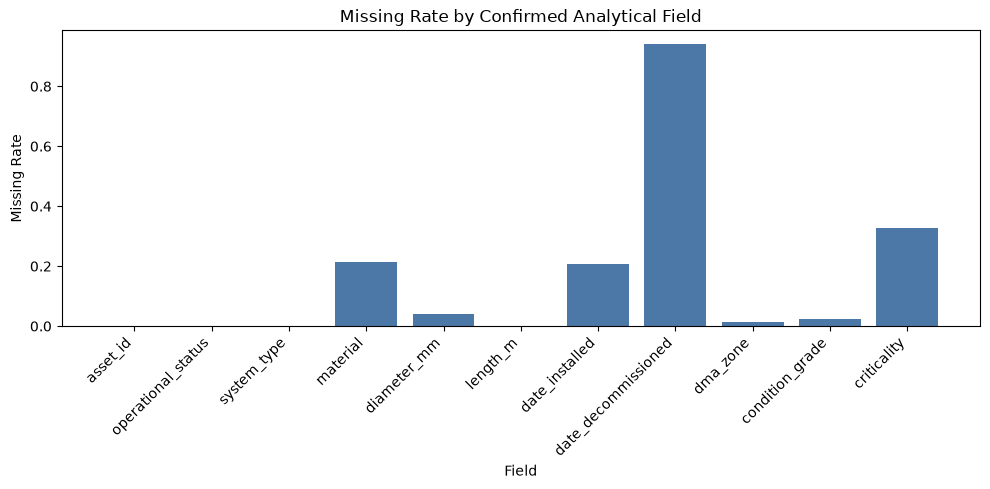

In [18]:
missing_value_chart = completeness_summary.copy()
plt.figure(figsize=(10, 5))
plt.bar(missing_value_chart["field_name"], missing_value_chart["missing_rate"], color="#4C78A8")
plt.title("Missing Rate by Confirmed Analytical Field")
plt.xlabel("Field")
plt.ylabel("Missing Rate")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(CHART_PATH / "missing_value_summary.png", dpi=150)
plt.show()

## 4. Asset Profile Analysis

This section describes what the cleaned pipe asset portfolio looks like before any renewal priority scoring is applied. The purpose is to understand the broad shape of the asset base, including material mix, age profile, diameter distribution, operational zone coverage, and the availability of condition and criticality fields.

### Load the cleaned analysis-ready dataset

The asset profile analysis uses the cleaned working dataset produced in Task 3. This keeps the profile section aligned with the same internal fields that will later support renewal screening.

In [19]:
profile_df = pd.read_csv(
    TABLE_PATH / "pipe_assets_cleaned.csv",
    parse_dates=["date_installed", "date_decommissioned"],
)

profile_df.head()

,asset_id,operational_status,system_type,material,diameter_mm,length_m,date_installed,date_decommissioned,dma_zone,condition_grade,criticality,asset_age,is_decommissioned,data_quality_flag,data_quality_issue_reason
0,GWRC_CI_PWP000001,In Use,Potable Water,STCL,375.0,0.62,1979-01-01,NaN,CBD,2.0,NaN,47.0,False,Major Issue,Missing criticality
1,GWRC_CI_PWP000002,In Use,Potable Water,CI,525.0,492.79,1911-01-01,NaN,CBD,NaN,NaN,115.0,False,Major Issue,Missing condition grade; Missing criticality
2,GWRC_CI_PWP000003,In Use,Potable Water,CI,525.0,0.32,1911-01-01,NaN,WCC CBD West,NaN,NaN,115.0,False,Major Issue,Missing condition grade; Missing criticality
3,GWRC_CI_PWP000004,In Use,Potable Water,STCL,375.0,13.80,1911-01-01,NaN,CBD,NaN,NaN,115.0,False,Major Issue,Missing condition grade; Missing criticality
4,GWRC_CI_PWP000005,In Use,Potable Water,NaN,150.0,2.37,1968-01-01,NaN,CBD,NaN,0.0,58.0,False,Data Review Required,Missing material


### Create asset profile summary tables

The tables in this section provide reusable summaries for the portfolio report. They focus on total pipe length and simple field distributions rather than any form of scoring.

In [20]:
profile_valid_length = profile_df["length_m"].notna() & (profile_df["length_m"] > 0)

material_summary = (
    profile_df.assign(material_group=profile_df["material"].fillna("Unknown"))
    .loc[profile_valid_length]
    .groupby("material_group", dropna=False)["length_m"]
    .sum()
    .sort_values(ascending=False)
    .rename_axis("material")
    .reset_index(name="total_length_m")
)
material_summary.to_csv(TABLE_PATH / "pipe_length_by_material.csv", index=False)

def assign_age_band(age):
    if pd.isna(age):
        return "Unknown"
    if age > 150:
        return "Age data review"
    if age <= 20:
        return "0-20"
    if age <= 40:
        return "21-40"
    if age <= 60:
        return "41-60"
    if age <= 80:
        return "61-80"
    return "80+"

profile_df["age_band"] = profile_df["asset_age"].apply(assign_age_band)
age_band_order = ["0-20", "21-40", "41-60", "61-80", "80+", "Unknown", "Age data review"]
age_band_summary = (
    profile_df.loc[profile_valid_length]
    .groupby("age_band")["length_m"]
    .sum()
    .reindex(age_band_order, fill_value=0)
    .rename_axis("age_band")
    .reset_index(name="total_length_m")
)
age_band_summary.to_csv(TABLE_PATH / "pipe_length_by_age_band.csv", index=False)

valid_diameter_mask = profile_df["diameter_mm"].notna() & (profile_df["diameter_mm"] > 0)
diameter_summary = pd.DataFrame([
    {"metric": "valid_record_count", "value": int(valid_diameter_mask.sum())},
    {"metric": "excluded_record_count", "value": int((~valid_diameter_mask).sum())},
    {"metric": "mean_diameter_mm", "value": round(profile_df.loc[valid_diameter_mask, "diameter_mm"].mean(), 2)},
    {"metric": "median_diameter_mm", "value": round(profile_df.loc[valid_diameter_mask, "diameter_mm"].median(), 2)},
    {"metric": "min_diameter_mm", "value": round(profile_df.loc[valid_diameter_mask, "diameter_mm"].min(), 2)},
    {"metric": "max_diameter_mm", "value": round(profile_df.loc[valid_diameter_mask, "diameter_mm"].max(), 2)},
])
diameter_summary.to_csv(TABLE_PATH / "diameter_summary.csv", index=False)

dma_zone_summary = (
    profile_df.assign(dma_zone_group=profile_df["dma_zone"].fillna("Unknown"))
    .loc[profile_valid_length]
    .groupby("dma_zone_group")["length_m"]
    .sum()
    .sort_values(ascending=False)
    .rename_axis("dma_zone")
    .reset_index(name="total_length_m")
)
dma_zone_summary.to_csv(TABLE_PATH / "pipe_length_by_dma_zone.csv", index=False)

condition_grade_summary = (
    profile_df["condition_grade"]
    .fillna("Unknown")
    .astype(str)
    .value_counts(dropna=False)
    .rename_axis("condition_grade")
    .reset_index(name="asset_count")
)
condition_grade_summary.to_csv(TABLE_PATH / "condition_grade_summary.csv", index=False)

criticality_summary = (
    profile_df["criticality"]
    .fillna("Unknown")
    .astype(str)
    .value_counts(dropna=False)
    .rename_axis("criticality")
    .reset_index(name="asset_count")
)
criticality_summary.to_csv(TABLE_PATH / "criticality_summary.csv", index=False)

material_summary.head()

,material,total_length_m
0,AC,859946.96
1,PE80,517564.54
2,PE100,356153.12
3,CI,341791.65
4,STCL,324845.16


### Material profile

This chart shows how total pipe length is distributed by material. Pipe length is used here rather than record count because longer assets represent more of the physical network portfolio.

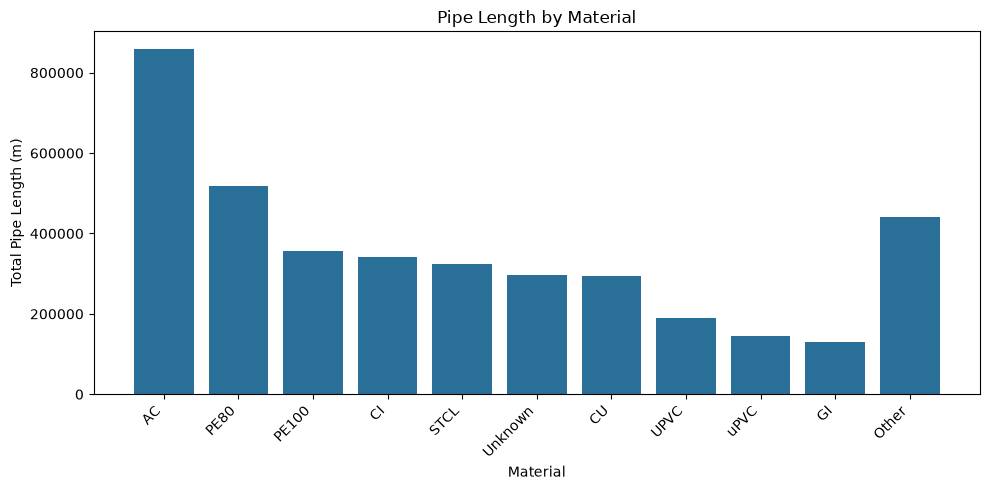

In [21]:
material_chart_data = material_summary.copy()
if len(material_chart_data) > 10:
    top_materials = material_chart_data.head(10).copy()
    other_length = material_chart_data.iloc[10:]["total_length_m"].sum()
    material_chart_data = pd.concat([
        top_materials,
        pd.DataFrame([{"material": "Other", "total_length_m": other_length}])
    ], ignore_index=True)

plt.figure(figsize=(10, 5))
plt.bar(material_chart_data["material"], material_chart_data["total_length_m"], color="#2A6F97")
plt.title("Pipe Length by Material")
plt.xlabel("Material")
plt.ylabel("Total Pipe Length (m)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(CHART_PATH / "pipe_length_by_material.png", dpi=150)
plt.show()

Finding: The largest measured pipe-length groups are `AC`, `PE80`, `PE100`, `CI`, and `STCL`, with `Unknown` material also representing a sizeable share of the network.

So what: The asset base is materially mixed rather than dominated by a single pipe type. That means later screening should consider both known material-related patterns and the limitation created by records where material is still unknown.

### Asset age distribution

This chart shows the spread of recorded asset ages based on `Date Installed`. It helps indicate whether the portfolio is concentrated in newer assets, older assets, or a wide age mix.

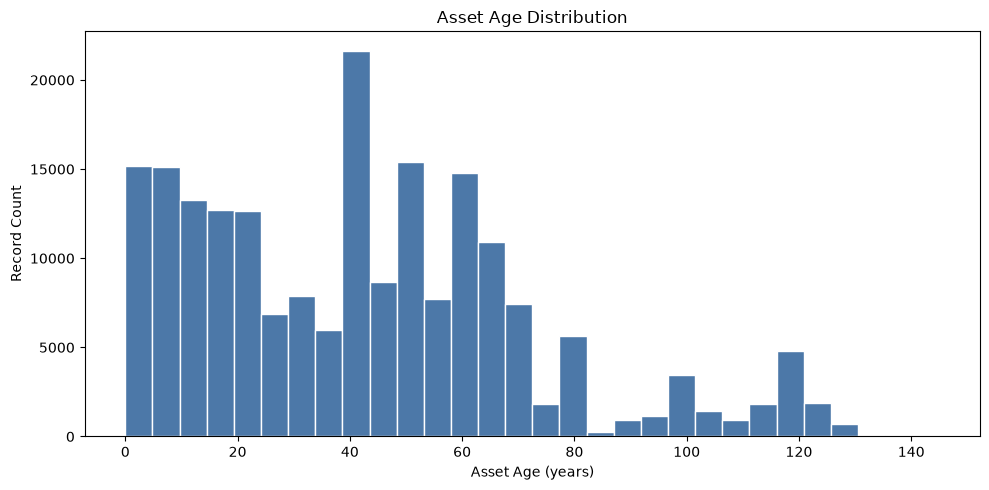

Excluded records with asset_age > 150 from the histogram as values requiring data review: 48


In [22]:
asset_age_histogram = profile_df["asset_age"].dropna()
excluded_age_review_count = int((asset_age_histogram > 150).sum())
asset_age_histogram = asset_age_histogram[(asset_age_histogram >= 0) & (asset_age_histogram <= 150)]

plt.figure(figsize=(10, 5))
plt.hist(asset_age_histogram, bins=30, color="#4C78A8", edgecolor="white")
plt.title("Asset Age Distribution")
plt.xlabel("Asset Age (years)")
plt.ylabel("Record Count")
plt.tight_layout()
plt.savefig(CHART_PATH / "asset_age_distribution.png", dpi=150)
plt.show()

print(f"Excluded records with asset_age > 150 from the histogram as values requiring data review: {excluded_age_review_count}")

Finding: The recorded age profile is broad, with a median age of about 41 years and an upper valid range extending to 145 years. A small number of records with age above 150 years were excluded from the histogram to avoid distorting the visual distribution, and were flagged for age data review.

So what: The portfolio includes both relatively recent and older assets, which supports the case for age-based profiling later on. At the same time, some installation dates still require review before age can be treated as fully reliable.

### Pipe length by age band

This view groups the network into broad age bands and measures total pipe length in each group. It is a simple way to understand where the physical network length is concentrated across different age ranges.

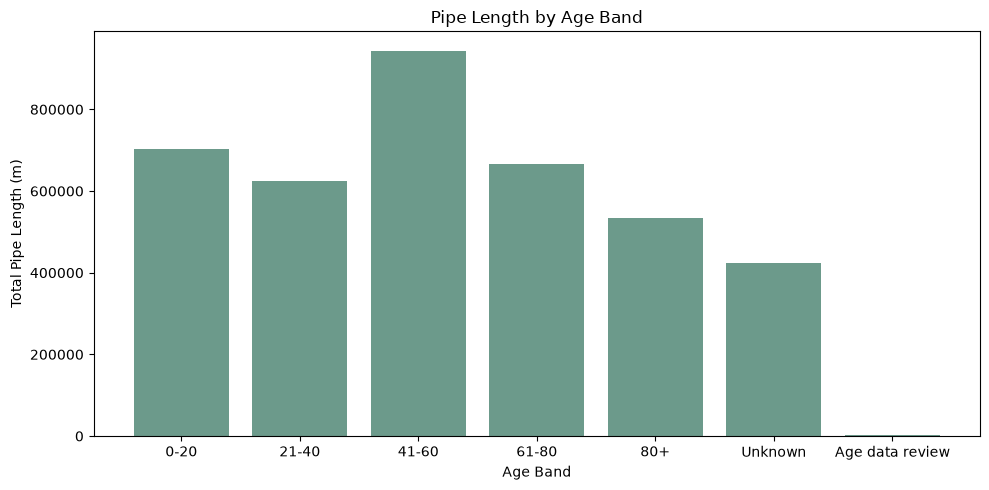

In [23]:
age_band_chart = age_band_summary.copy()

plt.figure(figsize=(10, 5))
plt.bar(age_band_chart["age_band"], age_band_chart["total_length_m"], color="#6C9A8B")
plt.title("Pipe Length by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Total Pipe Length (m)")
plt.tight_layout()
plt.savefig(CHART_PATH / "pipe_length_by_age_band.png", dpi=150)
plt.show()

Finding: The largest measured pipe length sits in the `41-60` year band, followed by substantial length in the `0-20`, `21-40`, `61-80`, and `80+` groups. There is also a visible `Unknown` segment where age could not be derived.

So what: The portfolio is not only old or only new. It contains meaningful length across several age cohorts, so later screening should consider both ageing pressure and the amount of network still sitting in records with incomplete age information.

### Diameter distribution

This chart groups valid pipe diameters into business-friendly size bands. A banded view is used here because the portfolio is heavily concentrated in smaller diameters, while a small number of very large pipes would otherwise stretch the axis and reduce readability.

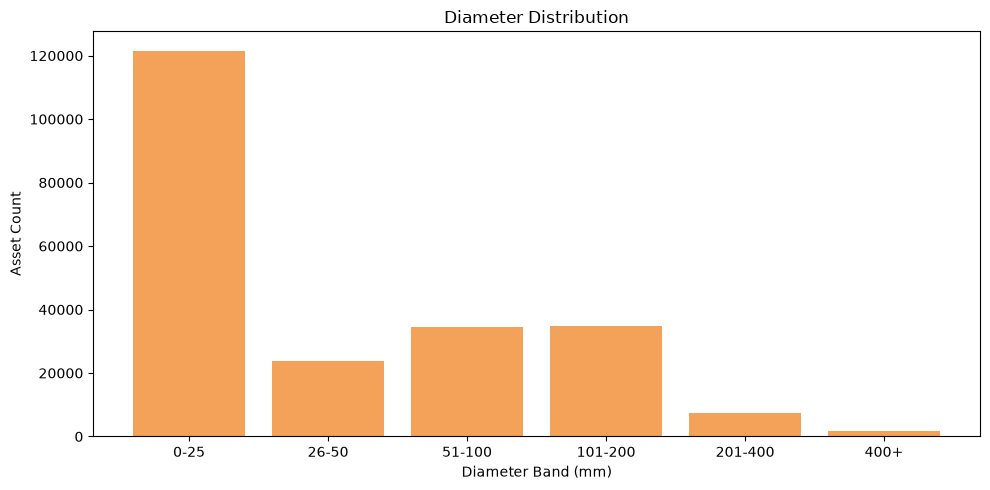

Excluded records with missing or non-positive diameter values: 29688


,diameter_band_mm,asset_count
0,0-25,121581
1,26-50,23715
2,51-100,34601
3,101-200,34941
4,201-400,7389
5,400+,1775


In [24]:
valid_diameter_values = profile_df.loc[valid_diameter_mask, "diameter_mm"]
excluded_diameter_count = int((~valid_diameter_mask).sum())

diameter_band_edges = [0, 25, 50, 100, 200, 400, np.inf]
diameter_band_labels = ["0-25", "26-50", "51-100", "101-200", "201-400", "400+"]
diameter_band_series = pd.cut(
    valid_diameter_values,
    bins=diameter_band_edges,
    labels=diameter_band_labels,
    include_lowest=True,
)
diameter_band_summary = (
    diameter_band_series.value_counts(sort=False)
    .rename_axis("diameter_band_mm")
    .reset_index(name="asset_count")
)

plt.figure(figsize=(10, 5))
plt.bar(diameter_band_summary["diameter_band_mm"].astype(str), diameter_band_summary["asset_count"], color="#F4A259")
plt.title("Diameter Distribution")
plt.xlabel("Diameter Band (mm)")
plt.ylabel("Asset Count")
plt.tight_layout()
plt.savefig(CHART_PATH / "diameter_distribution.png", dpi=150)
plt.show()

print(f"Excluded records with missing or non-positive diameter values: {excluded_diameter_count}")
diameter_band_summary

Finding: The diameter profile is concentrated in the smaller size bands, especially below 100 mm, while only a relatively small share of assets sits above 400 mm.

So what: A banded diameter view makes the structure of the portfolio easier to read without letting a small number of large pipes distort the chart scale. Larger assets remain important, but they should be interpreted as a smaller subset of the overall network.

### Operational zone profile

This chart looks at total pipe length by DMA Zone and highlights the largest zones in the cleaned dataset. It provides a simple view of where network length is concentrated geographically at an operational level.

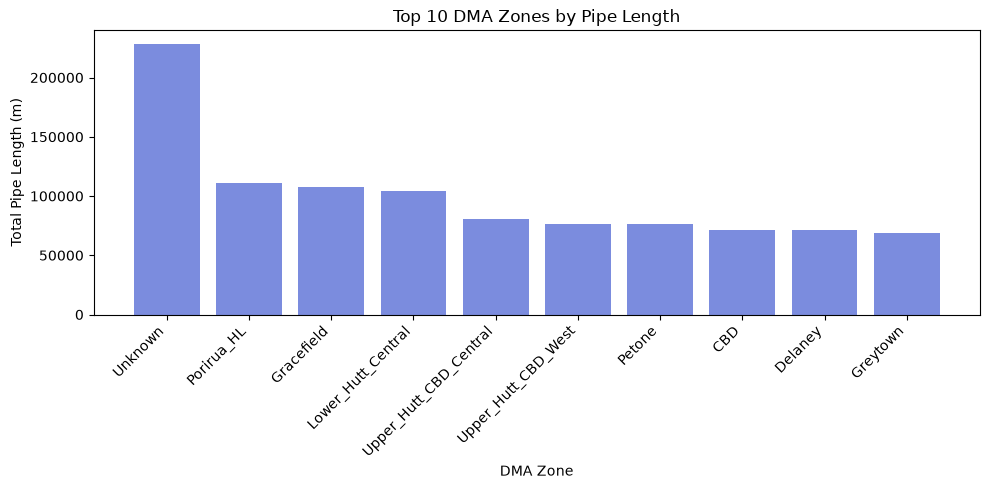

In [25]:
dma_zone_chart = dma_zone_summary.head(10).copy()

plt.figure(figsize=(10, 5))
plt.bar(dma_zone_chart["dma_zone"], dma_zone_chart["total_length_m"], color="#7B8CDE")
plt.title("Top 10 DMA Zones by Pipe Length")
plt.xlabel("DMA Zone")
plt.ylabel("Total Pipe Length (m)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(CHART_PATH / "pipe_length_by_dma_zone.png", dpi=150)
plt.show()

Finding: `Unknown` DMA Zone contributes the largest single grouped length, while named zones such as `Porirua_HL`, `Gracefield`, `Lower_Hutt_Central`, and `Upper_Hutt_CBD_Central` also contain substantial network length.

So what: The network length is spread across multiple operational zones rather than concentrated in one place. However, the size of the `Unknown` zone group means location-based analysis should be read with some caution until those records are better resolved.

### Condition grade and criticality profile

These charts provide a simple distribution view of `Condition Grade` and `Criticality`. They are useful as descriptive fields, but should be interpreted carefully because missing values remain material, especially for criticality.

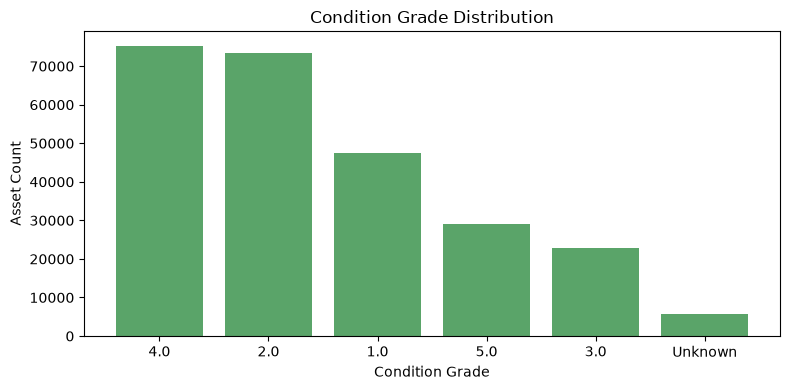

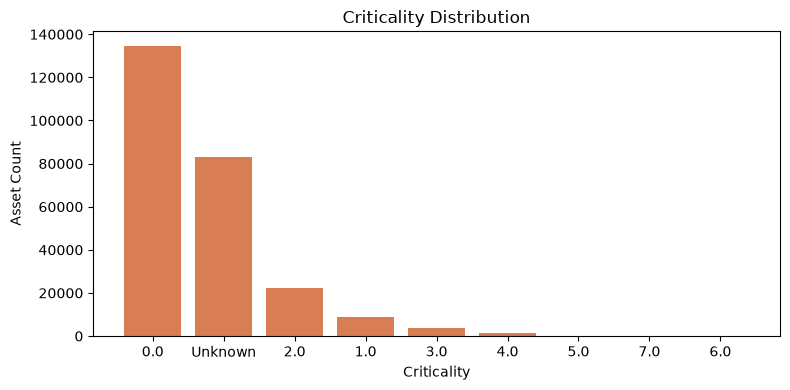

In [26]:
plt.figure(figsize=(8, 4))
plt.bar(condition_grade_summary["condition_grade"], condition_grade_summary["asset_count"], color="#5AA469")
plt.title("Condition Grade Distribution")
plt.xlabel("Condition Grade")
plt.ylabel("Asset Count")
plt.tight_layout()
plt.savefig(CHART_PATH / "condition_grade_distribution.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(criticality_summary["criticality"], criticality_summary["asset_count"], color="#D97D54")
plt.title("Criticality Distribution")
plt.xlabel("Criticality")
plt.ylabel("Asset Count")
plt.tight_layout()
plt.savefig(CHART_PATH / "criticality_distribution.png", dpi=150)
plt.show()

Finding: `Condition Grade` is populated across several recorded values, with grades `4.0`, `2.0`, and `1.0` appearing most often, while `Criticality` is dominated by `0.0` and a large `Unknown` category.

So what: Condition grade looks usable as a descriptive portfolio field, but criticality should be treated carefully because missingness remains high. Neither field should be interpreted as a direct risk result on its own at this stage.

### Cross-Attribute Asset Profile

The charts above describe individual asset attributes one at a time. This subsection adds two simple cross-attribute views to check whether key attributes differ across groups. These comparisons provide better context for later renewal priority screening without turning the analysis into a scoring model.

#### Median asset age by material

This view checks whether recorded asset age differs across material groups. It does not imply that material causes age differences. Instead, it provides a practical summary of how the portfolio appears to have been installed across different material eras.

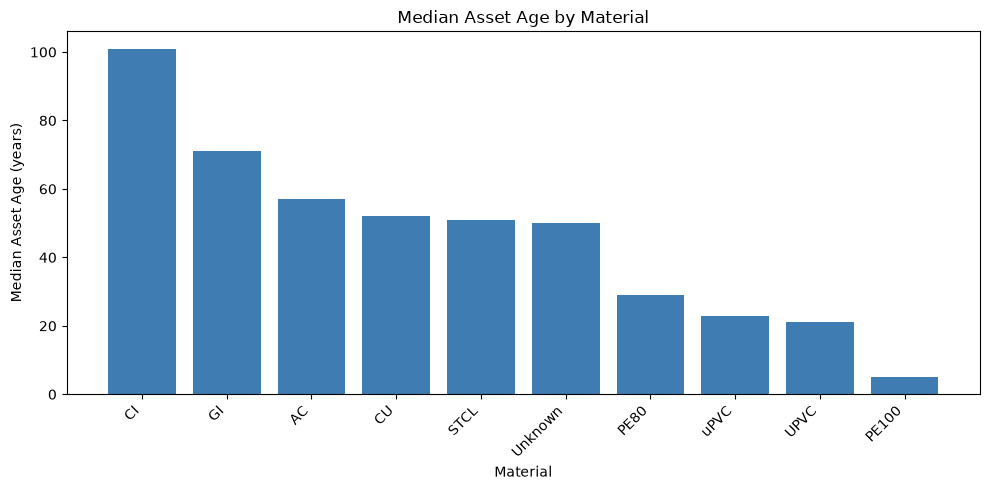

,material,median_asset_age
0,CI,101.0
1,GI,71.0
2,AC,57.0
3,CU,52.0
4,STCL,51.0
5,Unknown,50.0
6,PE80,29.0
7,uPVC,23.0
8,UPVC,21.0
9,PE100,5.0


In [27]:
profile_df["material_group"] = profile_df["material"].fillna("Unknown")
valid_age_profile = profile_df["asset_age"].notna() & (profile_df["asset_age"] >= 0) & (profile_df["asset_age"] <= 150)
top_10_materials = material_summary.head(10)["material"].tolist()

median_asset_age_by_material = (
    profile_df.loc[valid_age_profile & profile_df["material_group"].isin(top_10_materials)]
    .groupby("material_group")["asset_age"]
    .median()
    .sort_values(ascending=False)
    .rename_axis("material")
    .reset_index(name="median_asset_age")
)
median_asset_age_by_material.to_csv(TABLE_PATH / "median_asset_age_by_material.csv", index=False)

plt.figure(figsize=(10, 5))
plt.bar(median_asset_age_by_material["material"], median_asset_age_by_material["median_asset_age"], color="#3E7CB1")
plt.title("Median Asset Age by Material")
plt.xlabel("Material")
plt.ylabel("Median Asset Age (years)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(CHART_PATH / "median_asset_age_by_material.png", dpi=150)
plt.show()

median_asset_age_by_material

Finding: The profile suggests that median asset age differs across material groups, with `CI`, `GI`, and `AC` appearing older on average than newer groups such as `PE100`, `UPVC`, and `uPVC`.

So what: This may reflect historical installation patterns and provides useful context for renewal screening. Material should not be treated in isolation, but the age profile appears to vary meaningfully across material groups.

#### Pipe length by material and age band

This view checks how the age profile of the network differs across material groups when measured by total pipe length. It helps show whether some materials contain more older pipe length than others.

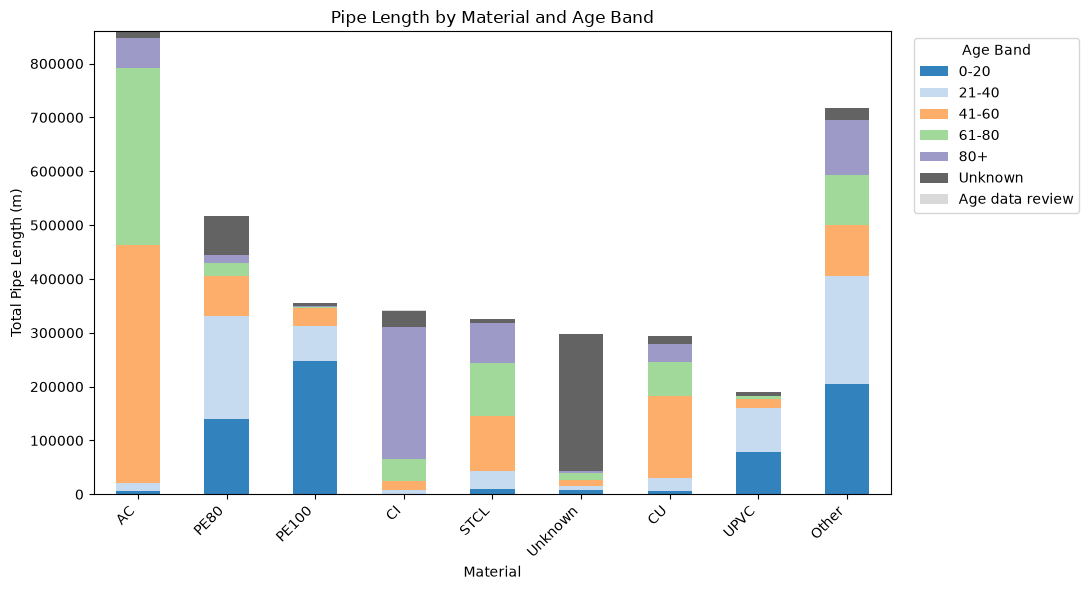

,material_top8,age_band,total_length_m
0,AC,0-20,6988.35
1,AC,21-40,13777.60
2,AC,41-60,442464.37
3,AC,61-80,328052.35
4,AC,80+,56235.24
5,AC,Unknown,12429.05
6,CI,0-20,1258.41
7,CI,21-40,6473.43
8,CI,41-60,16679.53
9,CI,61-80,41007.19


In [28]:
top_8_materials = material_summary.head(8)["material"].tolist()
profile_df["material_top8"] = profile_df["material_group"].where(profile_df["material_group"].isin(top_8_materials), "Other")
age_band_order = ["0-20", "21-40", "41-60", "61-80", "80+", "Unknown", "Age data review"]

pipe_length_by_material_age_band = (
    profile_df.loc[profile_valid_length]
    .groupby(["material_top8", "age_band"])["length_m"]
    .sum()
    .reset_index(name="total_length_m")
)
pipe_length_by_material_age_band.to_csv(TABLE_PATH / "pipe_length_by_material_age_band.csv", index=False)

material_age_band_chart = (
    pipe_length_by_material_age_band
    .pivot(index="material_top8", columns="age_band", values="total_length_m")
    .fillna(0)
    .reindex(columns=age_band_order, fill_value=0)
    .reindex(top_8_materials + ["Other"])
)

material_age_band_chart.plot(kind="bar", stacked=True, figsize=(11, 6), colormap="tab20c")
plt.title("Pipe Length by Material and Age Band")
plt.xlabel("Material")
plt.ylabel("Total Pipe Length (m)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Age Band", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(CHART_PATH / "pipe_length_by_material_age_band.png", dpi=150)
plt.show()

pipe_length_by_material_age_band.head(20)

Finding: The results indicate visible differences in age profile across material groups. For example, `AC` and `CI` contain substantial older pipe length, while `PE100` is concentrated more strongly in newer age bands.

So what: Renewal screening should consider the combination of material and age rather than treating each field separately. This cross-attribute view provides better context for how different parts of the network have developed over time.

## 5. Renewal Priority Screening

This section creates a lightweight renewal priority screening framework. The purpose is to identify assets that may require closer review, data improvement, or inclusion in future renewal planning discussions. It is not a failure prediction model and should not be used as a final engineering decision tool.

Screening Ready means the asset has sufficient core fields for this lightweight screening. It does not mean the record is complete or free from all data quality issues. The existing `data_quality_flag` is retained so data quality context is not lost.

### Load the cleaned dataset for screening

The screening section uses the cleaned analysis-ready dataset from Task 3. This keeps the scoring logic aligned with the same internal fields used in the data quality and asset profile stages.

In [29]:
screening_df = pd.read_csv(
    TABLE_PATH / "pipe_assets_cleaned.csv",
    parse_dates=["date_installed", "date_decommissioned"],
)

screening_df.head()

,asset_id,operational_status,system_type,material,diameter_mm,length_m,date_installed,date_decommissioned,dma_zone,condition_grade,criticality,asset_age,is_decommissioned,data_quality_flag,data_quality_issue_reason
0,GWRC_CI_PWP000001,In Use,Potable Water,STCL,375.0,0.62,1979-01-01,NaN,CBD,2.0,NaN,47.0,False,Major Issue,Missing criticality
1,GWRC_CI_PWP000002,In Use,Potable Water,CI,525.0,492.79,1911-01-01,NaN,CBD,NaN,NaN,115.0,False,Major Issue,Missing condition grade; Missing criticality
2,GWRC_CI_PWP000003,In Use,Potable Water,CI,525.0,0.32,1911-01-01,NaN,WCC CBD West,NaN,NaN,115.0,False,Major Issue,Missing condition grade; Missing criticality
3,GWRC_CI_PWP000004,In Use,Potable Water,STCL,375.0,13.80,1911-01-01,NaN,CBD,NaN,NaN,115.0,False,Major Issue,Missing condition grade; Missing criticality
4,GWRC_CI_PWP000005,In Use,Potable Water,NaN,150.0,2.37,1968-01-01,NaN,CBD,NaN,0.0,58.0,False,Data Review Required,Missing material


### Separate Data Review Required assets from Screening Ready assets

Assets already marked `Data Review Required` in the project-defined data quality rules are separated first. They are not forced into normal screening scores because the current record quality is not sufficient for a lightweight review score.

In [30]:
screening_df["screening_status"] = np.where(
    screening_df["data_quality_flag"].eq("Data Review Required"),
    "Data Review Required",
    "Screening Ready",
)

screening_status_summary = (
    screening_df["screening_status"]
    .value_counts()
    .rename_axis("screening_status")
    .reset_index(name="asset_count")
)
screening_status_summary["percentage_of_total"] = (screening_status_summary["asset_count"] / len(screening_df)).round(4)
screening_status_summary

,screening_status,asset_count,percentage_of_total
0,Screening Ready,191309,0.7541
1,Data Review Required,62381,0.2459


### Create simple rule-based score components

Only `Screening Ready` assets receive score components. The score is intentionally simple and transparent.

- `age_score` uses broad age bands
- `material_score` uses a project-defined mapping, not an engineering material standard
- `diameter_score` uses diameter as a simple service-impact proxy
- `condition_score` uses the project assumption that a higher `condition_grade` indicates poorer condition

For this screening exercise, condition grade is interpreted using the project assumption that a higher grade indicates poorer condition. This assumption should be validated against the source data dictionary before operational use.

In [31]:
screening_ready_mask = screening_df["screening_status"].eq("Screening Ready")

material_score_mapping = pd.DataFrame([
    {"material_category": "AC", "material_score": 3, "mapping_rationale": "older material group based on asset profile"},
    {"material_category": "CI", "material_score": 3, "mapping_rationale": "older material group based on asset profile"},
    {"material_category": "GI", "material_score": 3, "mapping_rationale": "older material group based on asset profile"},
    {"material_category": "STCL", "material_score": 2, "mapping_rationale": "legacy or mixed material group based on asset profile"},
    {"material_category": "EW", "material_score": 2, "mapping_rationale": "legacy or mixed material group based on asset profile"},
    {"material_category": "CONC", "material_score": 2, "mapping_rationale": "legacy or mixed material group based on asset profile"},
    {"material_category": "STEEL", "material_score": 2, "mapping_rationale": "legacy or mixed material group based on asset profile"},
    {"material_category": "PE80", "material_score": 1, "mapping_rationale": "newer plastic material group"},
    {"material_category": "PE100", "material_score": 1, "mapping_rationale": "newer plastic material group"},
    {"material_category": "PVC", "material_score": 1, "mapping_rationale": "newer plastic material group"},
    {"material_category": "uPVC", "material_score": 1, "mapping_rationale": "newer plastic material group"},
    {"material_category": "UPVC", "material_score": 1, "mapping_rationale": "newer plastic material group"},
])
material_score_mapping.to_csv(TABLE_PATH / "material_score_mapping.csv", index=False)

material_score_lookup = {
    row["material_category"]: (row["material_score"], row["mapping_rationale"])
    for _, row in material_score_mapping.iterrows()
}

def clean_material(value):
    if pd.isna(value):
        return np.nan
    text_value = str(value).strip()
    if not text_value or text_value.lower() == "unknown":
        return np.nan
    return text_value

screening_df["material_clean"] = screening_df["material"].apply(clean_material)

def assign_age_score(asset_age):
    if pd.isna(asset_age):
        return np.nan
    if asset_age <= 20:
        return 1
    if asset_age <= 40:
        return 2
    if asset_age <= 60:
        return 3
    if asset_age <= 80:
        return 4
    return 5

screening_df["age_score"] = np.where(
    screening_ready_mask,
    screening_df["asset_age"].apply(assign_age_score),
    np.nan,
)

material_scores = []
material_rationales = []
default_material_score_applied = []
for material_value in screening_df["material_clean"]:
    if pd.isna(material_value):
        material_scores.append(np.nan)
        material_rationales.append("unknown or missing material")
        default_material_score_applied.append(False)
    elif material_value in material_score_lookup:
        material_scores.append(material_score_lookup[material_value][0])
        material_rationales.append(material_score_lookup[material_value][1])
        default_material_score_applied.append(False)
    else:
        material_scores.append(2)
        material_rationales.append("default score applied due to limited interpretation")
        default_material_score_applied.append(True)

screening_df["material_score"] = np.where(screening_ready_mask, material_scores, np.nan)
screening_df["material_score_mapping_rationale"] = material_rationales
screening_df["default_material_score_applied"] = default_material_score_applied

valid_diameter_screening = screening_ready_mask & screening_df["diameter_mm"].notna() & (screening_df["diameter_mm"] > 0)
diameter_q1, diameter_q2, diameter_q3 = screening_df.loc[valid_diameter_screening, "diameter_mm"].quantile([0.25, 0.50, 0.75]).tolist()

def assign_diameter_score(diameter_value):
    if pd.isna(diameter_value):
        return np.nan
    if diameter_value <= diameter_q1:
        return 1
    if diameter_value <= diameter_q2:
        return 2
    if diameter_value <= diameter_q3:
        return 3
    return 4

screening_df["diameter_score"] = np.where(
    screening_ready_mask,
    screening_df["diameter_mm"].apply(assign_diameter_score),
    np.nan,
)

condition_grade_numeric = pd.to_numeric(screening_df["condition_grade"], errors="coerce")
screening_df["condition_score"] = np.where(
    screening_ready_mask,
    condition_grade_numeric.fillna(0),
    np.nan,
)

screening_df[["asset_id", "screening_status", "age_score", "material_score", "diameter_score", "condition_score"]].head()

,asset_id,screening_status,age_score,material_score,diameter_score,condition_score
0,GWRC_CI_PWP000001,Screening Ready,3.0,2.0,4.0,2.0
1,GWRC_CI_PWP000002,Screening Ready,5.0,3.0,4.0,0.0
2,GWRC_CI_PWP000003,Screening Ready,5.0,3.0,4.0,0.0
3,GWRC_CI_PWP000004,Screening Ready,5.0,2.0,4.0,0.0
4,GWRC_CI_PWP000005,Data Review Required,NaN,NaN,NaN,NaN


### Calculate review priority score and relative review tiers

The review score is a simple sum of the available screening components for `Screening Ready` assets only. Review tiers are then assigned from the score distribution of the screened portfolio.

These tiers are relative to the screened asset portfolio and should not be interpreted as absolute engineering risk categories.

In [32]:
screening_df["review_priority_score"] = np.where(
    screening_ready_mask,
    screening_df[["age_score", "material_score", "diameter_score", "condition_score"]].sum(axis=1, min_count=4),
    np.nan,
)

ready_score_q30 = screening_df.loc[screening_ready_mask, "review_priority_score"].quantile(0.30)
ready_score_q80 = screening_df.loc[screening_ready_mask, "review_priority_score"].quantile(0.80)

def assign_review_priority_tier(row):
    if row["screening_status"] == "Data Review Required":
        return "Data Review Required"
    if row["review_priority_score"] >= ready_score_q80:
        return "High Review Priority"
    if row["review_priority_score"] <= ready_score_q30:
        return "Lower Review Priority"
    return "Medium Review Priority"

screening_df["review_priority_tier"] = screening_df.apply(assign_review_priority_tier, axis=1)

review_priority_tier_summary = (
    screening_df["review_priority_tier"]
    .value_counts()
    .rename_axis("review_priority_tier")
    .reset_index(name="asset_count")
)
review_priority_tier_summary["percentage_of_total"] = (review_priority_tier_summary["asset_count"] / len(screening_df)).round(4)
review_priority_tier_summary.to_csv(TABLE_PATH / "review_priority_tier_summary.csv", index=False)

review_priority_tier_summary

,review_priority_tier,asset_count,percentage_of_total
0,Lower Review Priority,74969,0.2955
1,Data Review Required,62381,0.2459
2,Medium Review Priority,60217,0.2374
3,High Review Priority,56123,0.2212


### Create priority reasons and recommended actions

Each asset is given a short explanation so the screening output remains readable for business users. `Data Review Required` assets keep their existing quality issue reasons. Scored assets receive short descriptions based on the main contributing factors in the lightweight rule set.

In [33]:
diameter_top_quartile = screening_df.loc[screening_ready_mask, "diameter_mm"].quantile(0.75)

def build_priority_reason(row):
    if row["screening_status"] == "Data Review Required":
        issue_text = str(row["data_quality_issue_reason"]) if pd.notna(row["data_quality_issue_reason"]) else "key asset record review needed"
        if issue_text:
            return "Data review required: " + issue_text[:1].lower() + issue_text[1:]
        return "Data review required: key asset record review needed"

    reason_flags = []
    if pd.notna(row["asset_age"]) and row["asset_age"] >= 80:
        reason_flags.append("older asset")
    elif pd.notna(row["asset_age"]) and row["asset_age"] >= 61:
        reason_flags.append("moderate age")

    if pd.notna(row["material_score"]) and row["material_score"] >= 3:
        reason_flags.append("higher material concern")
    elif bool(row["default_material_score_applied"]):
        reason_flags.append("default material score applied")

    if pd.notna(row["diameter_mm"]) and row["diameter_mm"] >= diameter_top_quartile:
        reason_flags.append("larger diameter")

    if pd.notna(row["condition_grade"]) and float(row["condition_grade"]) >= 4:
        reason_flags.append("poorer condition grade")
    elif pd.isna(row["condition_grade"]):
        reason_flags.append("Condition grade unavailable")

    if {"older asset", "higher material concern", "larger diameter"}.issubset(set(reason_flags)):
        return "Older asset with higher material concern and larger diameter"
    if "older asset" in reason_flags and "poorer condition grade" in reason_flags:
        return "Older asset with poorer condition grade"
    if "larger diameter" in reason_flags and "moderate age" in reason_flags:
        return "Larger-diameter asset with moderate age"
    if not reason_flags:
        return "Lower screening score based on available fields"
    return "; ".join(reason_flags)

screening_df["priority_reason"] = screening_df.apply(build_priority_reason, axis=1)

recommended_action_mapping = {
    "Data Review Required": "Validate or complete key asset records before priority scoring.",
    "High Review Priority": "Review for possible inclusion in renewal planning or further engineering assessment.",
    "Medium Review Priority": "Monitor and consider during medium-term asset planning review.",
    "Lower Review Priority": "Maintain routine monitoring unless new condition or service information becomes available.",
}
screening_df["recommended_action"] = screening_df["review_priority_tier"].map(recommended_action_mapping)

screening_df[["asset_id", "review_priority_tier", "priority_reason", "recommended_action"]].head()

,asset_id,review_priority_tier,priority_reason,recommended_action
0,GWRC_CI_PWP000001,Medium Review Priority,larger diameter,Monitor and consider during medium-term asset ...
1,GWRC_CI_PWP000002,High Review Priority,Older asset with higher material concern and l...,Review for possible inclusion in renewal plann...
2,GWRC_CI_PWP000003,High Review Priority,Older asset with higher material concern and l...,Review for possible inclusion in renewal plann...
3,GWRC_CI_PWP000004,Medium Review Priority,older asset; larger diameter; Condition grade ...,Monitor and consider during medium-term asset ...
4,GWRC_CI_PWP000005,Data Review Required,Data review required: missing material,Validate or complete key asset records before ...


### Export the review priority list

The final screening output keeps the core asset context, the original data quality flag, the screening status, the score components, the resulting review tier, and the short business explanation for follow-up.

In [34]:
priority_output_columns = [
    "asset_id",
    "operational_status",
    "system_type",
    "material",
    "asset_age",
    "diameter_mm",
    "length_m",
    "dma_zone",
    "condition_grade",
    "criticality",
    "data_quality_flag",
    "screening_status",
    "age_score",
    "material_score",
    "diameter_score",
    "condition_score",
    "review_priority_score",
    "review_priority_tier",
    "priority_reason",
    "recommended_action",
]

priority_pipe_list = screening_df[priority_output_columns].copy()
priority_pipe_list.to_csv(OUTPUT_PATH / "priority_pipe_list.csv", index=False)

priority_pipe_list.head()

,asset_id,operational_status,system_type,material,asset_age,diameter_mm,length_m,dma_zone,condition_grade,criticality,data_quality_flag,screening_status,age_score,material_score,diameter_score,condition_score,review_priority_score,review_priority_tier,priority_reason,recommended_action
0,GWRC_CI_PWP000001,In Use,Potable Water,STCL,47.0,375.0,0.62,CBD,2.0,NaN,Major Issue,Screening Ready,3.0,2.0,4.0,2.0,11.0,Medium Review Priority,larger diameter,Monitor and consider during medium-term asset ...
1,GWRC_CI_PWP000002,In Use,Potable Water,CI,115.0,525.0,492.79,CBD,NaN,NaN,Major Issue,Screening Ready,5.0,3.0,4.0,0.0,12.0,High Review Priority,Older asset with higher material concern and l...,Review for possible inclusion in renewal plann...
2,GWRC_CI_PWP000003,In Use,Potable Water,CI,115.0,525.0,0.32,WCC CBD West,NaN,NaN,Major Issue,Screening Ready,5.0,3.0,4.0,0.0,12.0,High Review Priority,Older asset with higher material concern and l...,Review for possible inclusion in renewal plann...
3,GWRC_CI_PWP000004,In Use,Potable Water,STCL,115.0,375.0,13.80,CBD,NaN,NaN,Major Issue,Screening Ready,5.0,2.0,4.0,0.0,11.0,Medium Review Priority,older asset; larger diameter; Condition grade ...,Monitor and consider during medium-term asset ...
4,GWRC_CI_PWP000005,In Use,Potable Water,NaN,58.0,150.0,2.37,CBD,NaN,0.0,Data Review Required,Data Review Required,NaN,NaN,NaN,NaN,NaN,Data Review Required,Data review required: missing material,Validate or complete key asset records before ...


### Create summary outputs

These summaries show how the screened portfolio is distributed by review tier, which material groups contribute more high-review-priority assets, which age bands contribute more high-review-priority assets, and which issues most often drive `Data Review Required` status.

In [35]:
review_priority_by_material = (
    screening_df.assign(material_group=screening_df["material_clean"].fillna("Unknown"))
    .groupby("material_group")
    .agg(
        screening_ready_assets=("screening_status", lambda s: int((s == "Screening Ready").sum())),
        high_review_priority_assets=("review_priority_tier", lambda s: int((s == "High Review Priority").sum())),
    )
    .reset_index()
)
review_priority_by_material["high_review_priority_rate"] = np.where(
    review_priority_by_material["screening_ready_assets"] > 0,
    (review_priority_by_material["high_review_priority_assets"] / review_priority_by_material["screening_ready_assets"]).round(4),
    np.nan,
)
review_priority_by_material = review_priority_by_material.sort_values(["high_review_priority_assets", "screening_ready_assets"], ascending=[False, False])
review_priority_by_material.to_csv(TABLE_PATH / "review_priority_by_material.csv", index=False)

review_priority_by_age_band = (
    screening_df.assign(age_band=screening_df["asset_age"].apply(assign_age_band))
    .groupby("age_band")
    .agg(
        screening_ready_assets=("screening_status", lambda s: int((s == "Screening Ready").sum())),
        high_review_priority_assets=("review_priority_tier", lambda s: int((s == "High Review Priority").sum())),
    )
    .reindex(["0-20", "21-40", "41-60", "61-80", "80+", "Unknown", "Age data review"])
    .reset_index()
)
review_priority_by_age_band["high_review_priority_rate"] = np.where(
    review_priority_by_age_band["screening_ready_assets"] > 0,
    (review_priority_by_age_band["high_review_priority_assets"] / review_priority_by_age_band["screening_ready_assets"]).round(4),
    np.nan,
)
review_priority_by_age_band.to_csv(TABLE_PATH / "review_priority_by_age_band.csv", index=False)

data_review_required_summary = (
    screening_df.loc[screening_df["screening_status"].eq("Data Review Required"), "data_quality_issue_reason"]
    .fillna("Unknown data quality issue")
    .str.split("; ")
    .explode()
    .value_counts()
    .rename_axis("data_review_issue")
    .reset_index(name="asset_count")
)
data_review_required_summary["percentage_of_data_review_required"] = (
    data_review_required_summary["asset_count"] / screening_df["screening_status"].eq("Data Review Required").sum()
).round(4)
data_review_required_summary.to_csv(TABLE_PATH / "data_review_required_summary.csv", index=False)

review_priority_by_material.head(10)

,material_group,screening_ready_assets,high_review_priority_assets,high_review_priority_rate
1,AC,24063,21958,0.9125
9,CU,38112,12773,0.3351
6,CI,8980,8097,0.9017
33,STCL,11203,4559,0.4069
15,GI,4198,4022,0.9581
24,PE80,46990,2145,0.0456
30,ST,1565,803,0.5131
8,CICL,762,617,0.8097
16,GS,771,410,0.5318
22,PE,3233,189,0.0585


### Create simple review priority charts

These charts translate the screening summaries into business-friendly visuals. They do not show engineering risk. They show how the lightweight review priority categories are distributed within the project-defined screening framework.

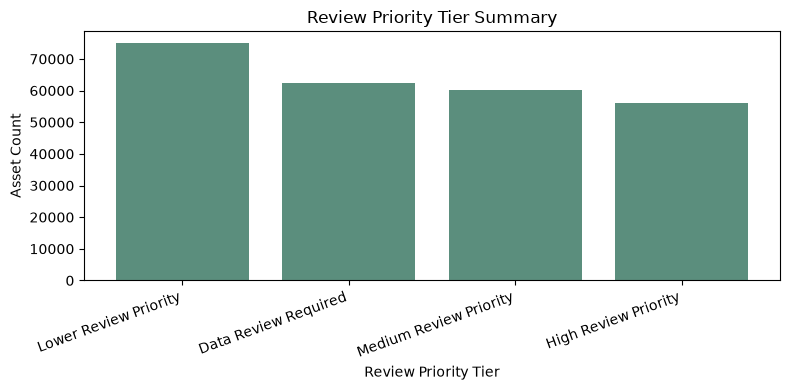

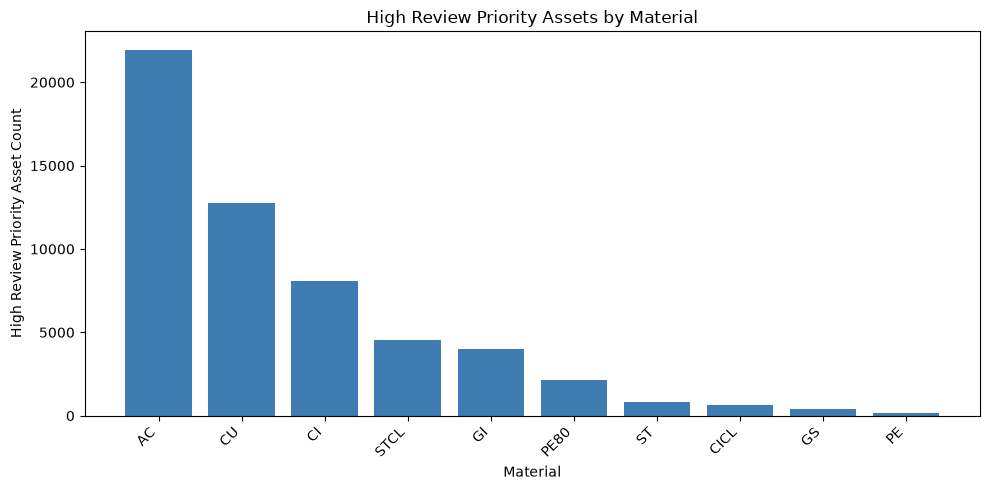

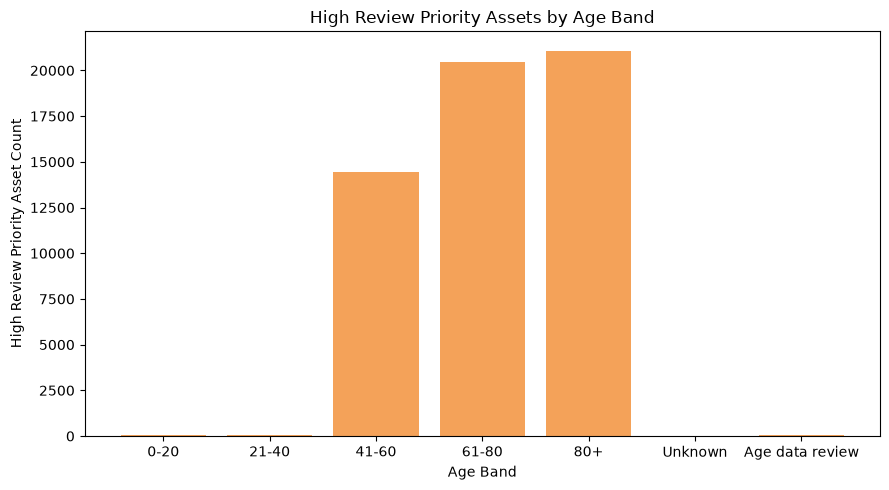

In [36]:
plt.figure(figsize=(8, 4))
plt.bar(review_priority_tier_summary["review_priority_tier"], review_priority_tier_summary["asset_count"], color="#5B8E7D")
plt.title("Review Priority Tier Summary")
plt.xlabel("Review Priority Tier")
plt.ylabel("Asset Count")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(CHART_PATH / "review_priority_tier_summary.png", dpi=150)
plt.show()

material_priority_chart = review_priority_by_material.head(10)
plt.figure(figsize=(10, 5))
plt.bar(material_priority_chart["material_group"], material_priority_chart["high_review_priority_assets"], color="#3E7CB1")
plt.title("High Review Priority Assets by Material")
plt.xlabel("Material")
plt.ylabel("High Review Priority Asset Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(CHART_PATH / "review_priority_by_material.png", dpi=150)
plt.show()

plt.figure(figsize=(9, 5))
plt.bar(review_priority_by_age_band["age_band"], review_priority_by_age_band["high_review_priority_assets"], color="#F4A259")
plt.title("High Review Priority Assets by Age Band")
plt.xlabel("Age Band")
plt.ylabel("High Review Priority Asset Count")
plt.tight_layout()
plt.savefig(CHART_PATH / "review_priority_by_age_band.png", dpi=150)
plt.show()

## 6. Export Outputs

This section will be completed in a later task.